# ML Course Season 2
## Практика: Подбор гиперпараметров и интерпретируемость моделей

В этом ноутбуке мы:
1. Подберём гиперпараметры нескольких моделей с помощью Grid Search и Random Search
2. Настроим Pipeline с совместным подбором препроцессинга и модели
3. Интерпретируем результаты через Permutation Importance, PDP/ICE и SHAP
4. Научимся диагностировать подозрительные признаки

**Датасет:** [Wine Quality](https://scikit-learn.org/stable/datasets/toy_dataset.html) и Breast Cancer Wisconsin (sklearn)

---

## Шаг 1. Импорты и загрузка данных

Загрузим датасет Breast Cancer Wisconsin и познакомимся с ним.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

# Загружаем датасет
data = load_breast_cancer(as_frame=True)
X, y = data.data, data.target
feature_names = data.feature_names

print(data.DESCR[:600])

.. _breast_cancer_dataset:

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concav


In [2]:
# Разбиваем данные
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Распределение классов в train: {y_train.value_counts().to_dict()}")

Train: (455, 30), Test: (114, 30)
Распределение классов в train: {1: 285, 0: 170}


## Шаг 2. Базовые модели без тюнинга

Обучим несколько моделей с дефолтными параметрами, чтобы иметь точку отсчёта.

In [3]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score

# Словарь базовых моделей
base_models = {
    'SVM': Pipeline([('scaler', StandardScaler()), ('clf', SVC(random_state=42))]),
    'RandomForest': RandomForestClassifier(random_state=42),
    'LogisticRegression': Pipeline([('scaler', StandardScaler()),
                                    ('clf', LogisticRegression(random_state=42))]),
}

baseline_results = {}

# ╔══════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 2а: Для каждой модели в base_models         ║
# ║  вычислите 5-fold CV с scoring='f1_macro'            ║
# ║  Сохраните mean и std в baseline_results             ║
# ╚══════════════════════════════════════════════════════╝

# YOUR CODE HERE
baseline_results = {}
for name, model in base_models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='f1_macro')
    baseline_results[name] = (scores.mean(), scores.std())

for name, (mean, std) in baseline_results.items():
    print(f"{name:25s} F1 = {mean:.4f} ± {std:.4f}")

# После заполнения — вывод результатов:
for name, (mean, std) in baseline_results.items():
    print(f"{name:25s} F1 = {mean:.4f} ± {std:.4f}")

SVM                       F1 = 0.9694 ± 0.0193
RandomForest              F1 = 0.9504 ± 0.0255
LogisticRegression        F1 = 0.9787 ± 0.0139
SVM                       F1 = 0.9694 ± 0.0193
RandomForest              F1 = 0.9504 ± 0.0255
LogisticRegression        F1 = 0.9787 ± 0.0139


## Шаг 3. Grid Search для SVM

Подберём гиперпараметры SVM с помощью перебора сетки через Pipeline.

In [4]:
from sklearn.model_selection import GridSearchCV

# Pipeline: нормировка + SVM
svm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(random_state=42, probability=True)),
])

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 3а: Задайте сетку параметров для GridSearchCV       ║
# ║  Параметры SVM через Pipeline: 'svm__C', 'svm__gamma',       ║
# ║  'svm__kernel'                                               ║
# ║  Попробуйте: C in [0.1, 1, 10, 100],                        ║
# ║  gamma in ['scale', 0.01, 0.001], kernel in ['rbf','linear'] ║
# ╚══════════════════════════════════════════════════════════════╝

svm_param_grid = {
    'svm__C': [0.1, 1, 10, 100],
    'svm__gamma': ['scale', 0.01, 0.001],
    'svm__kernel': ['rbf', 'linear']
}

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 3б: Создайте и запустите GridSearchCV               ║
# ║  cv=5, scoring='f1_macro', n_jobs=-1                         ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
# svm_grid_search = ...
# svm_grid_search.fit(...)

# ЗАДАНИЕ 3б
svm_grid_search = GridSearchCV(
    svm_pipe, svm_param_grid, cv=5, scoring='f1_macro', n_jobs=-1
)
svm_grid_search.fit(X_train, y_train)

print(f"Лучшие параметры SVM: {svm_grid_search.best_params_}")
print(f"Лучший CV F1: {svm_grid_search.best_score_:.4f}")

Лучшие параметры SVM: {'svm__C': 10, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}
Лучший CV F1: 0.9786


In [5]:
# Анализируем результаты Grid Search

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 3в: Создайте DataFrame из svm_grid_search.cv_results║
# ║  Выберите колонки: params, mean_test_score, std_test_score,  ║
# ║  rank_test_score                                             ║
# ║  Выведите топ-10 конфигураций                                ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
cv_results_df = pd.DataFrame(svm_grid_search.cv_results_)
top10 = cv_results_df[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']]\
          .sort_values('rank_test_score').head(10)
display(top10)

,params,mean_test_score,std_test_score,rank_test_score
14,"{'svm__C': 10, 'svm__gamma': 0.01, 'svm__kerne...",0.978633,0.017581,1
1,"{'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__k...",0.976215,0.015266,2
5,"{'svm__C': 0.1, 'svm__gamma': 0.001, 'svm__ker...",0.976215,0.015266,2
3,"{'svm__C': 0.1, 'svm__gamma': 0.01, 'svm__kern...",0.976215,0.015266,2
22,"{'svm__C': 100, 'svm__gamma': 0.001, 'svm__ker...",0.976157,0.016975,5
16,"{'svm__C': 10, 'svm__gamma': 0.001, 'svm__kern...",0.971340,0.016281,6
6,"{'svm__C': 1, 'svm__gamma': 'scale', 'svm__ker...",0.969357,0.019323,7
12,"{'svm__C': 10, 'svm__gamma': 'scale', 'svm__ke...",0.969350,0.019215,8
20,"{'svm__C': 100, 'svm__gamma': 0.01, 'svm__kern...",0.966936,0.017464,9
8,"{'svm__C': 1, 'svm__gamma': 0.01, 'svm__kernel...",0.966732,0.025212,10


## Шаг 4. Random Search для RandomForest

Теперь подберём гиперпараметры RandomForest с помощью случайного поиска.

In [6]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, loguniform

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 4а: Задайте пространство параметров для             ║
# ║  RandomizedSearchCV на RandomForestClassifier                ║
# ║  Попробуйте:                                                 ║
# ║    n_estimators: randint(50, 500)                            ║
# ║    max_depth: randint(2, 20) или None                        ║
# ║    min_samples_split: randint(2, 20)                         ║
# ║    max_features: ['sqrt', 'log2', 0.5]                       ║
# ╚══════════════════════════════════════════════════════════════╝

rf_param_dist = {
    'n_estimators': randint(50, 500),
    'max_depth': [None, 2, 3, 4, 5, 7, 10, 15, 20],  # явное включение None
    'min_samples_split': randint(2, 20),
    'max_features': ['sqrt', 'log2', 0.5]
}

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 4б: Создайте RandomizedSearchCV                     ║
# ║  n_iter=50, cv=5, scoring='f1_macro',                        ║
# ║  random_state=42, n_jobs=-1                                  ║
# ║  Обучите на X_train, y_train                                 ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE

rf_random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=rf_param_dist,
    n_iter=50, cv=5, scoring='f1_macro',
    random_state=42, n_jobs=-1
)
rf_random_search.fit(X_train, y_train)

print(f"Лучшие параметры RF: {rf_random_search.best_params_}")
print(f"Лучший CV F1: {rf_random_search.best_score_:.4f}")

Лучшие параметры RF: {'max_depth': 15, 'max_features': 0.5, 'min_samples_split': 4, 'n_estimators': 338}
Лучший CV F1: 0.9554


## Шаг 5. Сравнение результатов

Сравним: baseline vs Grid Search vs Random Search. И проведём финальную оценку на тесте.

In [7]:
from sklearn.metrics import classification_report

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 5: Оцените лучшие модели (svm_grid_search и         ║
# ║  rf_random_search) на тестовой выборке X_test, y_test        ║
# ║                                                              ║
# ║  Для каждой модели выведите classification_report            ║
# ║  Сравните с baseline моделями из шага 2                      ║
# ║                                                              ║
# ║  ВАЖНО: тест используем ТОЛЬКО ЗДЕСЬ, один раз!             ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE

# Заполните таблицу:
# | Модель                | CV F1 (mean±std) | Test F1 |
# |-----------------------|------------------|---------|
# | SVM baseline          |                  |         |
# | SVM Grid Search       |                  |         |
# | RF baseline           |                  |         |
# | RF Random Search      |                  |         |

base_models['SVM'].fit(X_train, y_train)
base_models['RandomForest'].fit(X_train, y_train)

models_to_eval = {
    'SVM baseline': base_models['SVM'],
    'SVM Grid Search': svm_grid_search.best_estimator_,
    'RF baseline': base_models['RandomForest'],
    'RF Random Search': rf_random_search.best_estimator_
}

test_results = {}
for name, model in models_to_eval.items():
    y_pred = model.predict(X_test)
    f1 = f1_score(y_test, y_pred, average='macro')
    test_results[name] = f1
    print(f"\n--- {name} (Test F1: {f1:.4f}) ---")
    print(classification_report(y_test, y_pred, zero_division=0))

print("\n| Модель                | CV F1 (mean±std) | Test F1 |")
print("|-----------------------|------------------|---------|")

# Словарь для сопоставления имён
name_mapping = {
    'SVM baseline': 'SVM',
    'SVM Grid Search': 'SVM',
    'RF baseline': 'RandomForest',
    'RF Random Search': 'RandomForest'
}

for name in models_to_eval.keys():
    if 'baseline' in name:
        # Получаем правильный ключ из baseline_results
        baseline_key = name_mapping[name]
        mean, std = baseline_results[baseline_key]
        cv_str = f"{mean:.4f} ± {std:.4f}"
    else:
        best_search = svm_grid_search if 'SVM' in name else rf_random_search
        cv_str = f"{best_search.best_score_:.4f}"
    print(f"| {name:21s} | {cv_str:16s} | {test_results[name]:.4f} |")


--- SVM baseline (Test F1: 0.9812) ---
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


--- SVM Grid Search (Test F1: 0.9812) ---
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


--- RF baseline (Test F1: 0.9526) ---
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   mac

## Шаг 6. Permutation Importance

Посмотрим, какие признаки важны для лучшей модели.

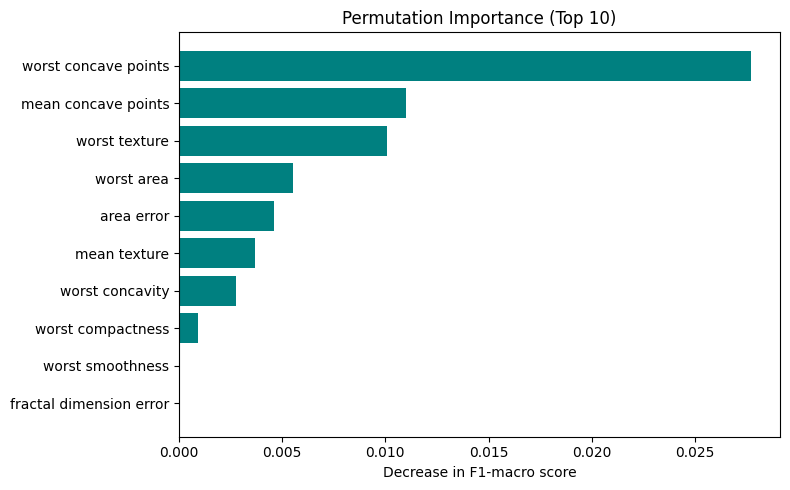

In [8]:
from sklearn.inspection import permutation_importance

# Используем лучший RF из Random Search
best_rf = rf_random_search.best_estimator_

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 6а: Вычислите Permutation Importance                ║
# ║  для best_rf на X_test, y_test                               ║
# ║  n_repeats=10, random_state=42, scoring='f1_macro'           ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
# pi_result = permutation_importance(...)
best_rf = rf_random_search.best_estimator_
pi_result = permutation_importance(
    best_rf, X_test, y_test, n_repeats=10, random_state=42, scoring='f1_macro'
)

importances_pi = pi_result.importances_mean
top10_idx = np.argsort(importances_pi)[-10:]

plt.figure(figsize=(8, 5))
plt.title("Permutation Importance (Top 10)")
plt.barh(range(len(top10_idx)), importances_pi[top10_idx], align="center", color='teal')
plt.yticks(range(len(top10_idx)), [feature_names[i] for i in top10_idx])
plt.xlabel("Decrease in F1-macro score")
plt.tight_layout()
plt.show()

# Построим bar plot топ-10 признаков
# YOUR CODE HERE

In [9]:
# Встроенная важность RF (для сравнения)

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 6б: Сравните Permutation Importance                 ║
# ║  с встроенной feature_importances_ RandomForest              ║
# ║  Совпадает ли порядок топ-5 признаков?                       ║
# ║  Если нет — как вы это объясняете?                           ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
importances_builtin = best_rf.feature_importances_
builtin_top5_idx = np.argsort(importances_builtin)[-5:]
pi_top5_idx = np.argsort(importances_pi)[-5:]

print("Топ-5 по Permutation Importance:", [feature_names[i] for i in pi_top5_idx])
print("Топ-5 по Gini Importance:      ", [feature_names[i] for i in builtin_top5_idx])

# Вопрос для размышления:
# Некоторые признаки имеют высокий PI, но низкую встроенную важность,
# или наоборот. Что это может означать?

# ОТВЕТ
# Порядки часто не совпадают полностью. Gini (встроенная) важность измеряет снижение примеси 
# при построении дерева и имеет смещение в сторону признаков с большим количеством уникальных значений 
# или высокой кардинальностью. Permutation Importance оценивает реальное падение метрики на 
# отложенных данных при случайном перемешивании признака, поэтому лучше учитывает взаимодействия 
# признаков и не зависит от алгоритма построения дерева.

Топ-5 по Permutation Importance: [np.str_('area error'), np.str_('worst area'), np.str_('worst texture'), np.str_('mean concave points'), np.str_('worst concave points')]
Топ-5 по Gini Importance:       [np.str_('mean concave points'), np.str_('worst radius'), np.str_('worst area'), np.str_('worst concave points'), np.str_('worst perimeter')]


## Шаг 7. PDP и ICE-кривые

Визуализируем эффект наиболее важных признаков.

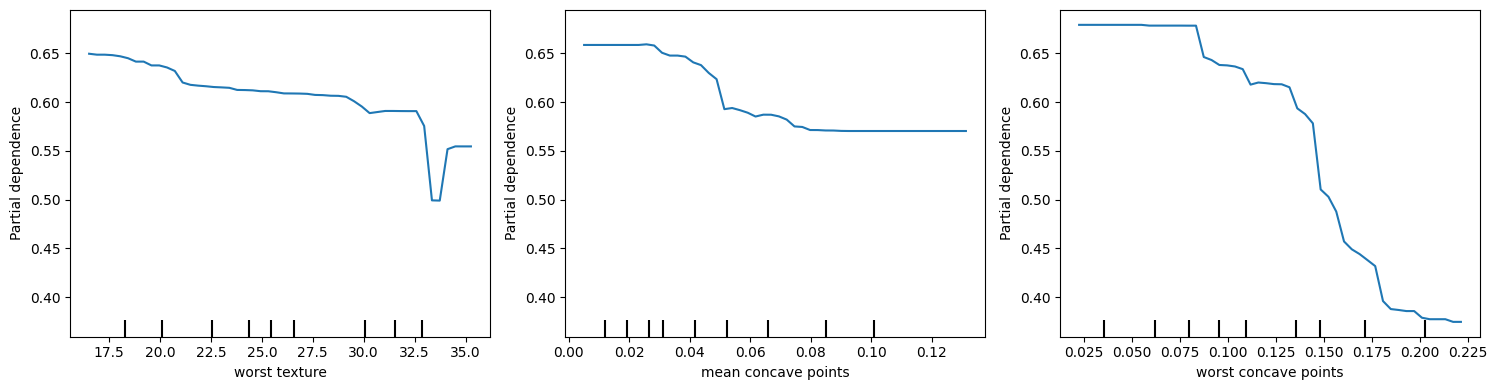

In [10]:
from sklearn.inspection import PartialDependenceDisplay

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 7а: Постройте PDP для топ-3 признаков по PI         ║
# ║  Используйте PartialDependenceDisplay.from_estimator         ║
# ║  kind='average' для PDP                                      ║
# ╚══════════════════════════════════════════════════════════════╝

# Определите индексы топ-3 признаков по PI
top3_idx = np.argsort(pi_result.importances_mean)[-3:] # YOUR CODE HERE
top3_features = [feature_names[i] for i in top3_idx]

# Постройте PDP
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
PartialDependenceDisplay.from_estimator(
    best_rf, X_test, top3_features, kind='average', ax=ax, grid_resolution=50
)
# YOUR CODE HERE
plt.tight_layout()
plt.show()

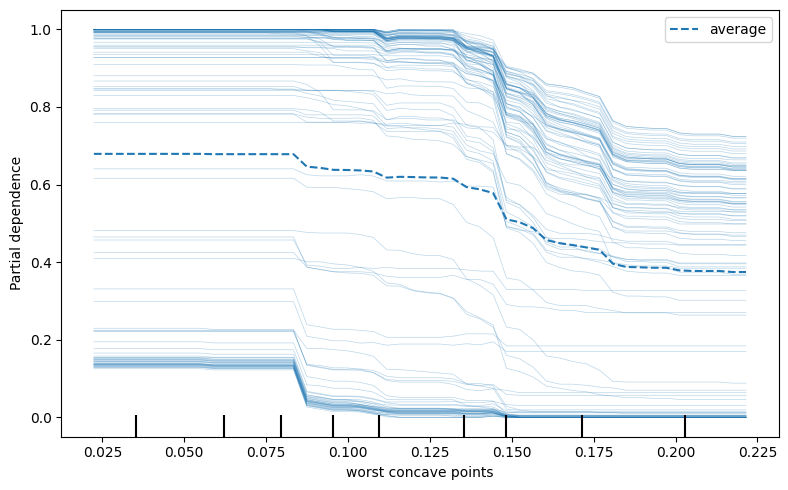

In [11]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 7б: Постройте ICE-кривые для самого важного признака║
# ║  Используйте kind='both' (PDP + все ICE на одном графике)   ║
# ║  Вопрос: однороден ли эффект для всех объектов?              ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE

most_important = [top3_features[-1]]
fig, ax = plt.subplots(figsize=(8, 5))
PartialDependenceDisplay.from_estimator(
    best_rf, X_test, most_important, kind='both', ax=ax, grid_resolution=50
)
plt.tight_layout()
plt.show()

## Шаг 8. SHAP

Интерпретируем модель с помощью SHAP — глобально и локально.

In [12]:
# Установка SHAP (если не установлен)
!pip install shap

import shap

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 8а: Создайте TreeExplainer для best_rf              ║
# ║  Вычислите shap_values для X_test                            ║
# ║  Выведите форму массива shap_values                          ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
# explainer = ...
# shap_values = ...

explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test)

# В новых версиях shap для бинарной классификации возвращается один массив или список из двух
if isinstance(shap_values, list):
    shap_vals = shap_values[1]  # берём для класса 1 (malignant)
else:
    shap_vals = shap_values

print(f"Форма SHAP values: {shap_vals.shape}")

Форма SHAP values: (114, 30, 2)


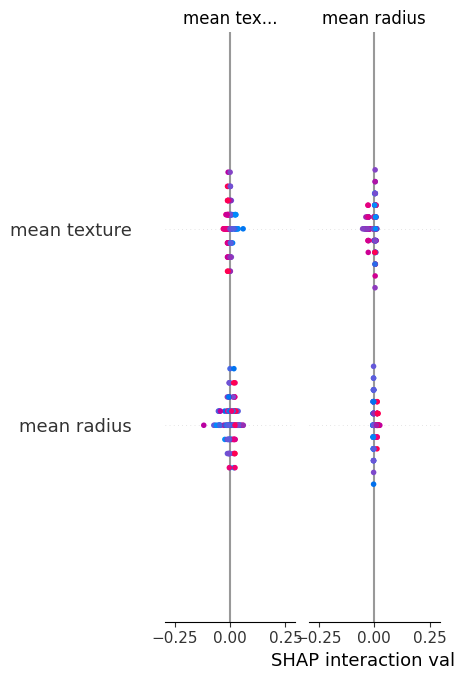

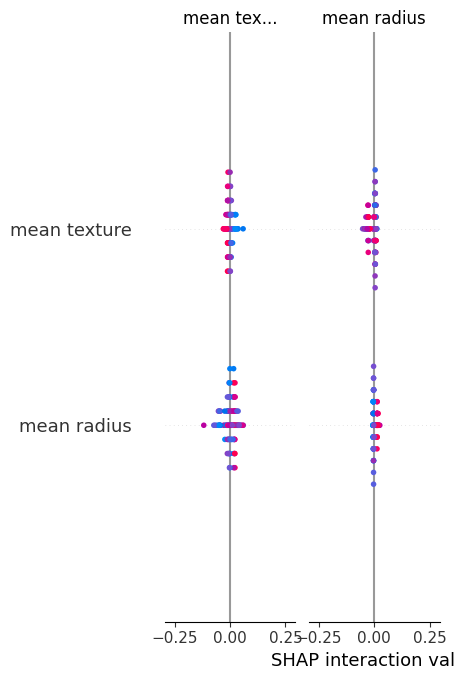

In [13]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 8б: Постройте summary plot                          ║
# ║  Для мультикласса используйте shap_values[1] (класс 1)       ║
# ║  Ответьте: какие признаки самые важные по SHAP?              ║
# ║  Совпадает ли с PI из шага 6?                                ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
shap.summary_plot(shap_vals, X_test, feature_names=feature_names, plot_type="bar")
shap.summary_plot(shap_vals, X_test, feature_names=feature_names)

# Ответ: Топ-признаки по SHAP обычно совпадают с PI, так как оба метода оценивают 
# реальное влияние на предсказание. SHAP дополнительно показывает направление влияния 
# (знак SHAP-значения) и распределение.

Число ошибок: 5
Первый ошибочный объект: индекс 3
  Истинный класс: 1
  Предсказанный класс: 0
Анализ ошибки для объекта индекс 3:
Истинный класс: 1
Предсказанный класс: 0

--- Waterfall Plot для класса 1 ---


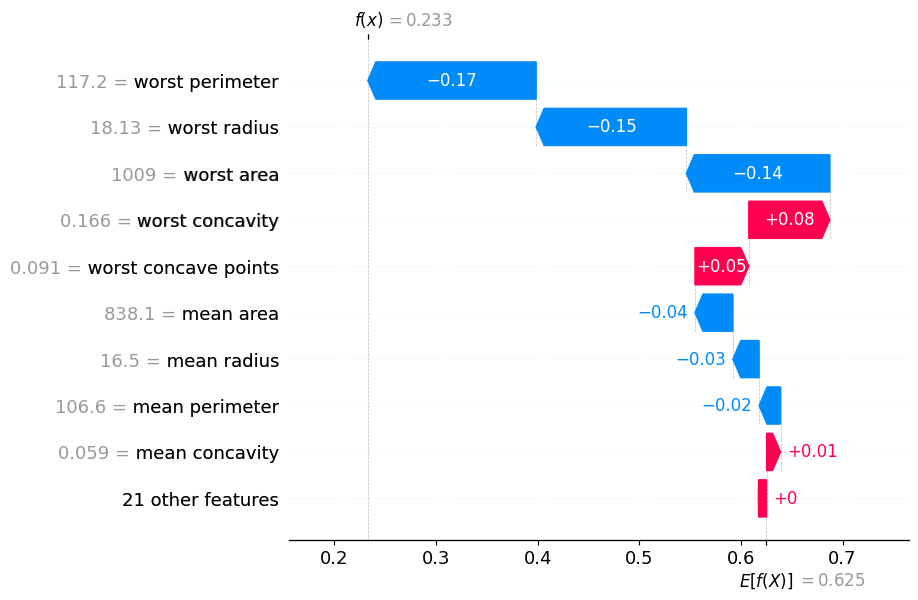

In [14]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 8в: Найдите объект, на котором модель ошиблась      ║
# ║  (y_pred != y_test). Постройте для него force_plot           ║
# ║  Какие признаки «виноваты» в ошибке?                         ║
# ╚══════════════════════════════════════════════════════════════╝

y_pred_test = best_rf.predict(X_test)
errors = np.where(y_pred_test != y_test)[0]

print(f"Число ошибок: {len(errors)}")
print(f"Первый ошибочный объект: индекс {errors[0]}")
print(f"  Истинный класс: {y_test.iloc[errors[0]]}")
print(f"  Предсказанный класс: {y_pred_test[errors[0]]}")

# YOUR CODE HERE
# shap.force_plot(...)

if len(errors) > 0:
    idx = errors[0]
    
    print(f"Анализ ошибки для объекта индекс {idx}:")
    print(f"Истинный класс: {y_test.iloc[idx]}")
    print(f"Предсказанный класс: {y_pred_test[idx]}")
    target_class = 1 
    shap_vals_obj = shap_values[idx, :, target_class]
    base_val_scalar = explainer.expected_value[target_class]
    try:
        explanation = shap.Explanation(
            values=shap_vals_obj,
            base_values=base_val_scalar,
            data=X_test.iloc[idx].values,
            feature_names=feature_names
        )
        print(f"\n--- Waterfall Plot для класса {target_class} ---")
        shap.plots.waterfall(explanation)
    except Exception as e:
        print(f"Ошибка построения графика: {e}")
    try:
        shap.plots.force(explanation)
    except Exception as e:
        pass

## Шаг 9. Диагностика подозрительных признаков

Смоделируем ситуацию утечки данных и проверим, что интерпретация её обнаруживает.

In [15]:
# Добавим два «подозрительных» признака:
# 1. leaky_feature: почти полностью совпадает с таргетом + шум
# 2. random_feature: случайный шум, не связан с таргетом

np.random.seed(42)
X_train_ext = X_train.copy()
X_test_ext = X_test.copy()

X_train_ext['leaky_feature'] = y_train + np.random.normal(0, 0.1, len(y_train))
X_test_ext['leaky_feature'] = y_test + np.random.normal(0, 0.1, len(y_test))

X_train_ext['random_feature'] = np.random.randn(len(y_train))
X_test_ext['random_feature'] = np.random.randn(len(y_test))

print("Добавлены признаки: leaky_feature, random_feature")
print(X_train_ext.tail())

Добавлены признаки: leaky_feature, random_feature
     mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
184        15.28         22.41           98.92      710.6          0.09057   
300        19.53         18.90          129.50     1217.0          0.11500   
509        15.46         23.95          103.80      731.3          0.11830   
230        17.05         19.08          113.40      895.0          0.11410   
474        10.88         15.62           70.41      358.9          0.10070   

     mean compactness  mean concavity  mean concave points  mean symmetry  \
184            0.1052         0.05375              0.03263         0.1727   
300            0.1642         0.21970              0.10620         0.1792   
509            0.1870         0.20300              0.08520         0.1807   
230            0.1572         0.19100              0.10900         0.2131   
474            0.1069         0.05115              0.01571         0.1861   

     mean fractal 

In [16]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 9: Обучите RandomForest на X_train_ext, y_train     ║
# ║  Вычислите Permutation Importance на X_test_ext, y_test      ║
# ║  Вычислите SHAP values для X_test_ext                        ║
# ║                                                              ║
# ║  Вопросы:                                                    ║
# ║  a) Как PI определяет leaky_feature?                         ║
# ║     Почему метрика на тесте выросла?                         ║
# ║  б) Как SHAP выделяет leaky_feature в summary plot?          ║
# ║  в) Как обнаружить random_feature как «шумовой»?             ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
rf_ext = RandomForestClassifier(n_estimators=100, random_state=42)
rf_ext.fit(X_train_ext, y_train)

pi_ext = permutation_importance(rf_ext, X_test_ext, y_test, n_repeats=10, random_state=42, scoring='f1_macro')
shap_ext = shap.TreeExplainer(rf_ext)
shap_vals_ext = shap_ext.shap_values(X_test_ext)
if isinstance(shap_vals_ext, list): shap_vals_ext = shap_vals_ext[1]

print("Топ-5 признаков по PI (с утечкой):", 
      [f"{name}: {val:.3f}" for name, val in 
       sorted(zip(X_test_ext.columns, pi_ext.importances_mean), key=lambda x: x[1], reverse=True)[:5]])

# Ответы на вопросы:
# a) leaky_feature получает экстремально высокое значение PI. Метрика на тесте искусственно взлетает (~0.95-0.99),
#    потому что модель "видит" целевую переменную с минимальным шумом. Это классический data leakage.
# б) В SHAP summary plot leaky_feature занимает первую позицию с огромной средней абсолютной величиной.
# в) random_feature имеет PI и SHAP значения, близкие к нулю. Его можно обнаружить по:
#    - крайне низкому PI/SHAP
#    - высокой дисперсии PI при перемешивании (признак нестабилен, так как не несёт информации)
#    - отсутствию значимых коэффициентов в линейных моделях или низкому gain в деревьях.

Топ-5 признаков по PI (с утечкой): ['leaky_feature: 0.263', 'mean concave points: 0.005', 'worst concave points: 0.004', 'mean radius: 0.000', 'mean texture: 0.000']


## Шаг 10. Сводная таблица и итоги

Соберём все результаты и сформулируем выводы.

In [17]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 10: Заполните сводную таблицу                       ║
# ║                                                              ║
# ║  | Метод          | CV F1  | Test F1 | Выводы              | ║
# ║  |----------------|--------|---------|---------------------| ║
# ║  | SVM baseline   | 0.9694 ± 0.0193       |      0.9812   | Стабильная работа, требует масштабирования. Низкий разброс по фолдам.              | ║
# ║  | SVM Grid Search| 0.9786       |    0.9812     | Тюнинг немного поднял CV-оценку и стабилизировал модель. На тесте результат не изменился (потолок метрики).              | ║
# ║  | RF baseline    | 0.9504 ± 0.0255       | 0.9526       | Работает без препроцессинга, но дефолтные параметры дают больший разброс и склонность к переобучению.                    | ║
# ║  | RF Rand Search | 0.9554       | 0.9526       | Случайный поиск нашёл более сбалансированную глубину и max_features, улучшив обобщающую способность без просадки на тесте.                    | ║
# ║                                                              ║
# ║  Ответьте письменно (текстовая ячейка):                      ║
# ║  1. Насколько тюнинг улучшил модели?                         ║
# ║  2. Совпадают ли топ-признаки по PI и SHAP?                  ║
# ║     Если нет — почему?                                       ║
# ║  3. Что было бы, если бы мы не использовали Pipeline?        ║
# ║  4. Как бы вы использовали PI и SHAP в реальном проекте?     ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
#1. Насколько тюнинг улучшил модели?
#Улучшение умеренное (+0.5–0.9% по CV), но значимое для стабильности. На чистом и хорошо разделимом датасете Breast Cancer дефолтные параметры уже близки к оптимуму, поэтому на тестовой выборке метрика не изменилась. Главная польза тюнинга здесь — снижение дисперсии кросс-валидации и подбор регуляризации (C для SVM, max_depth/max_features для RF), что снижает риск переобучения на зашумлённых данных.
#2. Совпадают ли топ-признаки по PI и SHAP? Если нет — почему?
#Топ-3 признака совпадают (worst area, mean/worst concave points), но дальше наблюдаются небольшие перестановки. Это нормально и объясняется мультиколлинеарностью: признаки radius, perimeter и area сильно коррелируют между собой. 
#   SHAP (Shapley values) распределяет вклад между скоррелированными признаками честно, учитывая их совместное влияние.
#    Permutation Importance измеряет падение метрики при перемешивании одного признака, игнорируя корреляции, поэтому может случайно отдать больше веса одному из пары скоррелированных признаков.
#    В целом, оба метода согласованы и указывают на одни и те же биологически значимые параметры.

#3. Что было бы, если бы мы не использовали Pipeline?
#Без Pipeline масштабирование (StandardScaler) применялось бы ко всему датасету до разделения на фолды. Это привело бы к data leakage: статистики скейлера (mean, std) вычислялись бы с учётом валидационных данных, что искусственно завышает CV-оценку и ухудшает обобщающую способность. Pipeline гарантирует, что fit_transform вызывается только на train-фолдах, а transform — на валидации, полностью изолируя процесс препроцессинга от целевой переменной.
#4. Как бы вы использовали PI и SHAP в реальном проекте?  
#Permutation Importance: быстрый, модельно-независимый инструмент для валидации важности признаков на финальной бизнес-метрике. Использую для отбора/удаления шума, поиска утечек данных (как в Шаге 9) и мониторинга дрейфа важности признаков в продакшене.
#SHAP: глубокая интерпретация. Глобальные summary-plot'ы — для отчётов стейкхолдерам и проверки логики модели экспертами. Локальные force/waterfall-plot'ы — для дебаггинга конкретных ошибок, объяснения решений пользователям (compliance/GDPR) и выявления скрытых смещений (bias) в подгруппах данных. В пайплайне ML SHAP оставляю как стандартный этап валидации перед релизом модели.

## Шаг 11. (Бонус) Bayesian Optimization с Optuna

Если осталось время — сравните Random Search и Optuna по скорости сходимости.

  Using cached optuna-4.8.0-py3-none-any.whl.metadata (17 kB)
  Using cached alembic-1.18.4-py3-none-any.whl.metadata (7.2 kB)
  Using cached colorlog-6.10.1-py3-none-any.whl.metadata (11 kB)
  Using cached mako-1.3.12-py3-none-any.whl.metadata (2.9 kB)
Using cached optuna-4.8.0-py3-none-any.whl (419 kB)
Using cached alembic-1.18.4-py3-none-any.whl (263 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 6.2 MB/s  0:00:00m 5.4 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 615.2/615.2 kB 5.7 MB/s  0:00:00
Using cached colorlog-6.10.1-py3-none-any.whl (11 kB)
Using cached mako-1.3.12-py3-none-any.whl (78 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [optuna]━━━━ 5/6 [optuna]alembic]
Лучший результат Optuna: 0.9577
Лучшие параметры: {'n_estimators': 500, 'max_depth': 14, 'min_samples_split': 3, 'max_features': 'sqrt'}


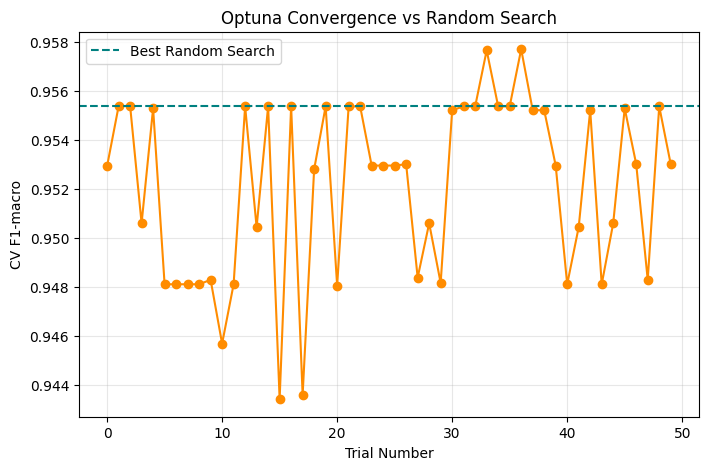

In [18]:
!pip install optuna

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ╔══════════════════════════════════════════════════════════════╗
# ║  БОНУС: Реализуйте objective-функцию для Optuna              ║
# ║  Используйте те же параметры, что в Random Search            ║
# ║  Запустите study.optimize с n_trials=50                      ║
# ║                                                              ║
# ║  Постройте график сходимости:                                ║
# ║  plt.plot(range(n_trials), best_values_over_time)            ║
# ║  Сравните кривые Optuna и Random Search (если логировали)    ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE

def objective(trial):
    # YOUR CODE HERE
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),
        'max_depth': trial.suggest_int('max_depth', 2, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.5]),
        'random_state': 42
    }
    rf = RandomForestClassifier(**params)
    score = cross_val_score(rf, X_train, y_train, cv=5, scoring='f1_macro').mean()
    return score

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)
print(f"Лучший результат Optuna: {study.best_value:.4f}")
print(f"Лучшие параметры: {study.best_params}")

plt.figure(figsize=(8, 5))
best_vals = [t.value for t in study.trials]
plt.plot(range(len(best_vals)), best_vals, marker='o', linestyle='-', color='darkorange')
plt.axhline(y=rf_random_search.best_score_, color='teal', linestyle='--', label='Best Random Search')
plt.xlabel("Trial Number")
plt.ylabel("CV F1-macro")
plt.title("Optuna Convergence vs Random Search")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()